In [1]:
# We use dysh_data to retrieve the example data set.
from dysh.util.files import dysh_data
from pathlib import Path

# This is required to load and calibrate the example data set.
from dysh.fits.gbtfitsload import GBTFITSLoad
from dysh.log import init_logging

In [2]:
init_logging(2)

# also create a local "output" directory where temporary notebook files can be stored.
output_dir = Path.cwd() / "output"
output_dir.mkdir(exist_ok=True)

In [3]:
filename = dysh_data(example='otf1')

16:06:04.921 I Resolving example=otf1 -> mapping-L/data/TGBT17A_506_11.raw.vegas/TGBT17A_506_11.raw.vegas.A.fits


In [4]:
sdfits = GBTFITSLoad(filename)

16:06:06.813 I Index loaded from .index file (44/93 columns). Missing columns (TCAL, WCS, calibration metadata, etc.) will be automatically loaded from FITS file when first accessed.


In [5]:
sdfits.summary()

SCAN,OBJECT,VELOCITY,PROC,PROCSEQN,RESTFREQ,# IF,# POL,# INT,# FEED,AZIMUTH,ELEVATION
6,3C286,0.0,OnOff,1,1.6168,5,2,13,1,248.3657,72.5531
7,3C286,0.0,OnOff,2,1.6168,5,2,13,1,250.0385,73.6777
8,SgrB2M,57.0,Track,1,1.6168,5,2,61,1,142.3845,12.2545
9,W33B,64.0,Track,1,1.6168,5,2,61,1,132.2057,17.9786
10,G30.589-0.044,38.0,Track,1,1.6168,5,2,61,1,115.4811,25.5523
11,G31.412+0.307,97.0,Track,1,1.6168,5,2,61,1,115.8034,27.0986
12,G35.577-0.029,49.0,Track,1,1.6168,5,2,61,1,112.3139,29.0337
13,G40.622-0.137,32.0,Track,1,1.6168,5,2,61,1,107.7736,31.3159
14,NGC6946,45.0,DecLatMap,1,1.6168,5,2,61,1,38.9626,41.3644
15,NGC6946,45.0,DecLatMap,2,1.6168,5,2,61,1,38.9910,41.4488


In [6]:
ifnum = 0                     # The 21 cm line is in the spectral window labeled 0.
fdnum = 0                     # Only one feed in this data set
ref   = 27                    # The reference ("OFF") scan
scans = list(range(14,27))    # The signal ("ON") scans 14..26

In [7]:
sb0 = sdfits.getsigref(scan=scans, ref=ref, fdnum=fdnum, ifnum=ifnum, plnum=0)

16:06:12.837 I Ignoring 1 blanked integration(s).


16:06:14.828 I Ignoring 1 blanked integration(s).


16:06:15.415 I Ignoring 1 blanked integration(s).


16:06:16.024 I Ignoring 1 blanked integration(s).


16:06:16.615 I Ignoring 1 blanked integration(s).


...

16:06:19.764 I Ignoring 1 blanked integration(s).


16:06:20.385 I Ignoring 1 blanked integration(s).


16:06:20.968 I Ignoring 1 blanked integration(s).


16:06:21.566 I Ignoring 1 blanked integration(s).


16:06:22.161 I Ignoring 1 blanked integration(s).


In [8]:
sb0

ScanBlock([PSScan scan=14 ifnum=0 (rest freq=1.42 GHz) plnum=0 (YY) fdnum=0 source='NGC6946',
           PSScan scan=15 ifnum=0 (rest freq=1.42 GHz) plnum=0 (YY) fdnum=0 source='NGC6946',
           PSScan scan=16 ifnum=0 (rest freq=1.42 GHz) plnum=0 (YY) fdnum=0 source='NGC6946',
           PSScan scan=17 ifnum=0 (rest freq=1.42 GHz) plnum=0 (YY) fdnum=0 source='NGC6946',
           PSScan scan=18 ifnum=0 (rest freq=1.42 GHz) plnum=0 (YY) fdnum=0 source='NGC6946',
           PSScan scan=19 ifnum=0 (rest freq=1.42 GHz) plnum=0 (YY) fdnum=0 source='NGC6946',
           PSScan scan=20 ifnum=0 (rest freq=1.42 GHz) plnum=0 (YY) fdnum=0 source='NGC6946',
           PSScan scan=21 ifnum=0 (rest freq=1.42 GHz) plnum=0 (YY) fdnum=0 source='NGC6946',
           PSScan scan=22 ifnum=0 (rest freq=1.42 GHz) plnum=0 (YY) fdnum=0 source='NGC6946',
           PSScan scan=23 ifnum=0 (rest freq=1.42 GHz) plnum=0 (YY) fdnum=0 source='NGC6946',
           PSScan scan=24 ifnum=0 (rest freq=1.42 GHz) plnum

In [9]:
nint = sb0[len(sb0)//2].nint
print(nint)
spec = sb0[len(sb0)//2].getspec(nint//2)

60


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


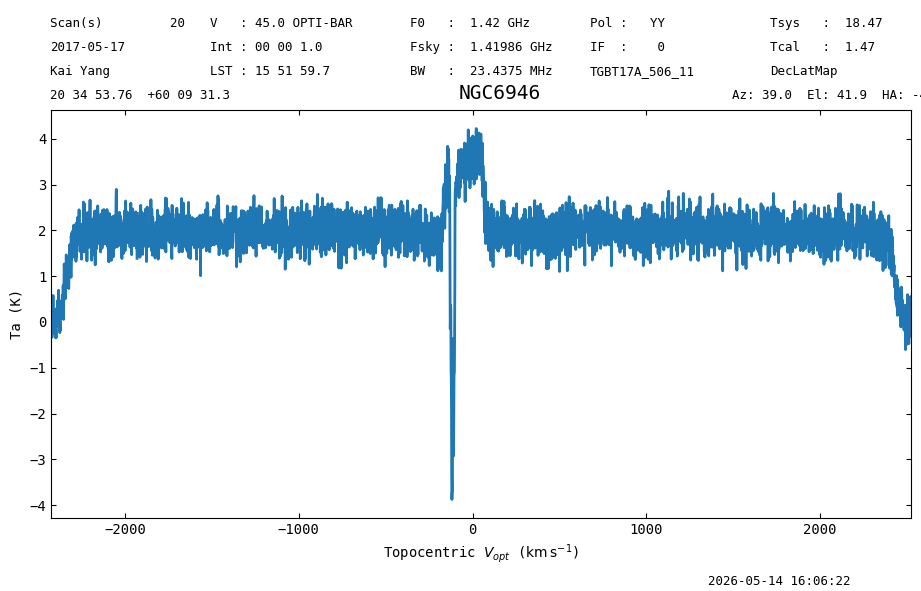

In [10]:
sp = spec.plot(xaxis_unit="km/s")

In [11]:
spec_avg = sb0[len(sb0)//2].timeaverage()

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


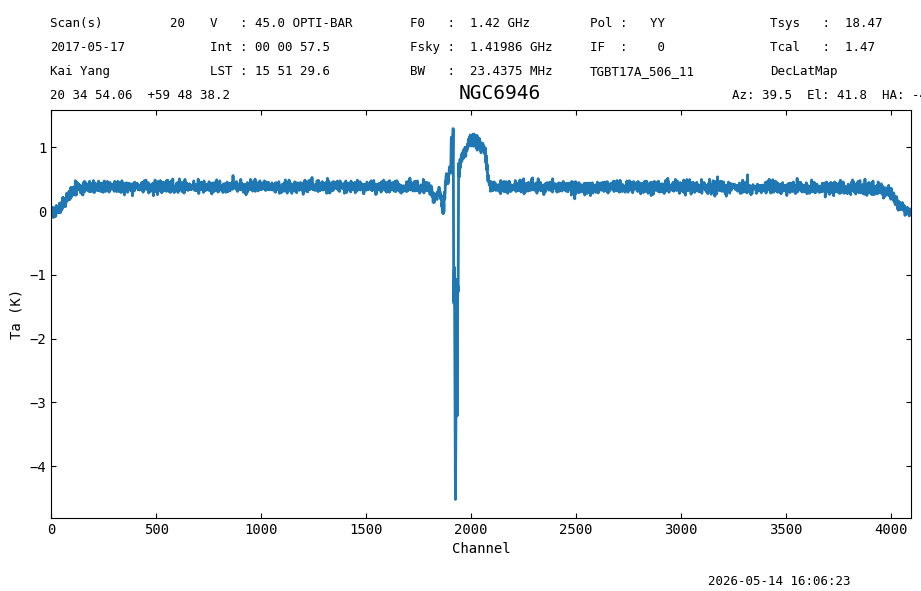

In [12]:
sp_avg = spec_avg.plot(xaxis_unit="channel")

In [13]:
exclude = [(0,250),
           (1600,2250),
           (4095-250,4095)]

In [14]:
spec_avg.baseline(1, model="poly", exclude=exclude, remove=True)

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


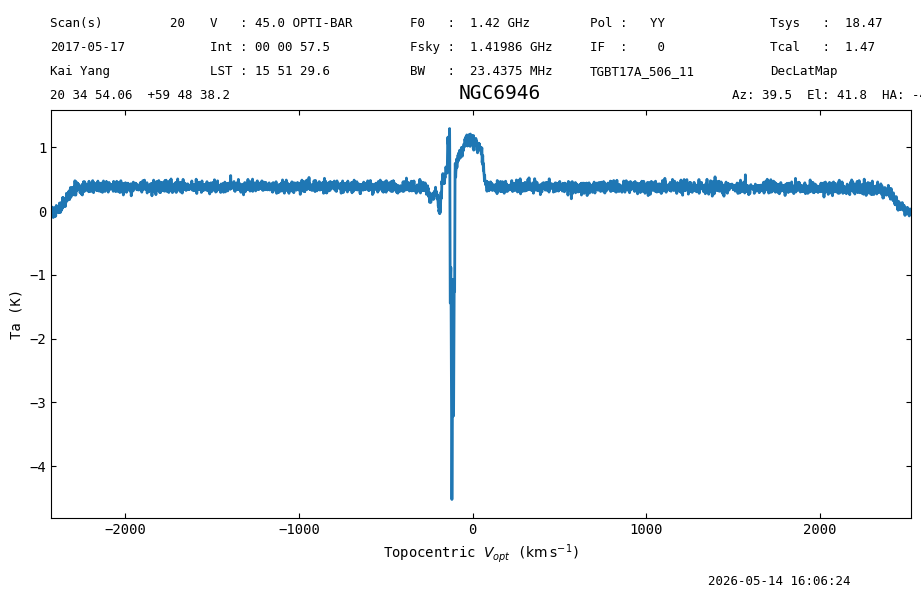

In [15]:
sp_avg.plot(xaxis_unit = "km/s")

In [16]:
spec_avg[250:1600].stats()  

16:06:24.628 I Note: found 1 NaN (masked) values


{'mean': <Quantity -0.00040599 K>,
 'median': <Quantity -0.00123781 K>,
 'rms': <Quantity 0.04531066 K>,
 'min': <Quantity -0.14616574 K>,
 'max': <Quantity 0.17465374 K>,
 'npt': 1350,
 'nan': np.int64(1)}

In [17]:
sb0[len(sb0)//2].subtract_baseline(spec_avg.baseline_model)

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


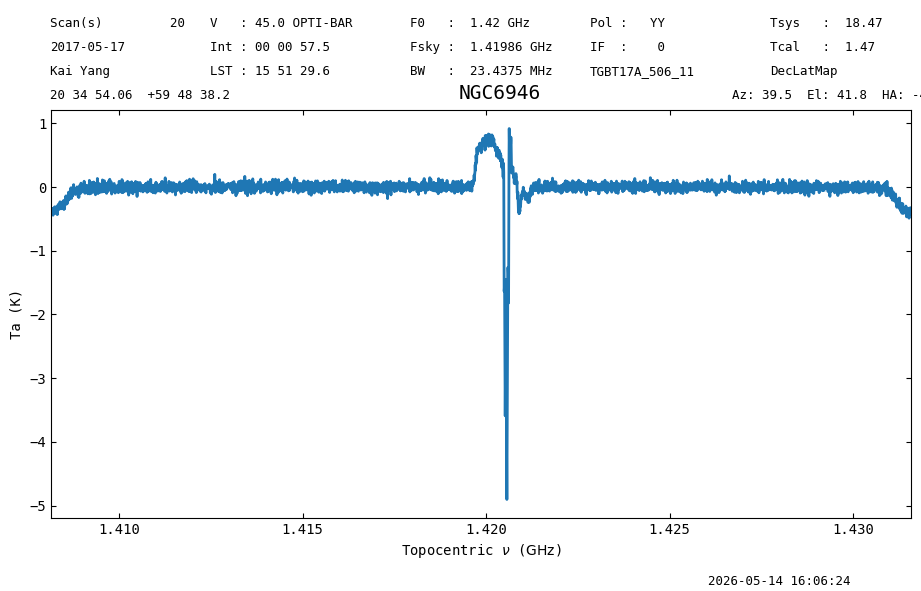

In [18]:
spec_avg_bsub = sb0[len(sb0)//2].timeaverage()
sp_avg_bsub = spec_avg_bsub.plot()

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


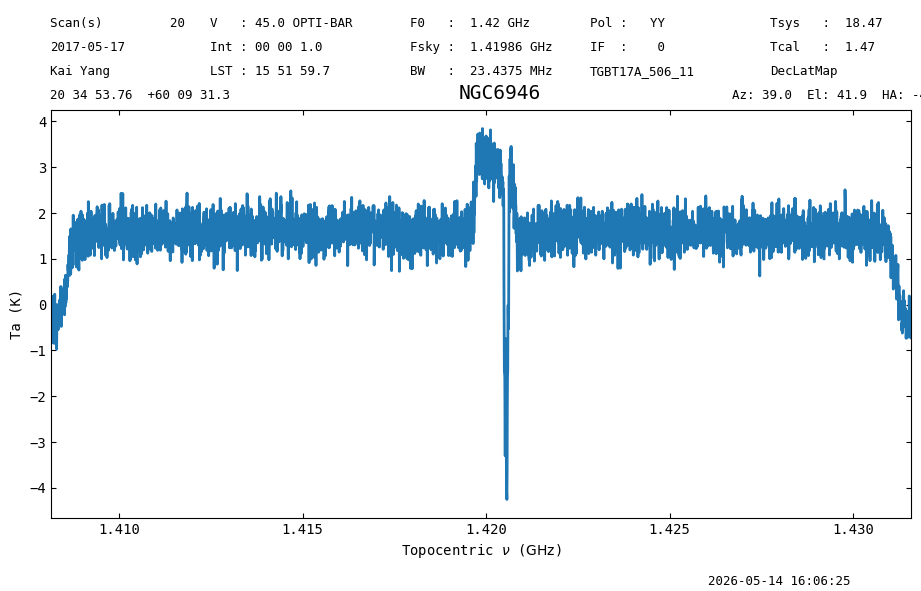

In [19]:
spec_bsub = sb0[len(sb0)//2].getspec(nint//2)
sp_spec_bsub = spec_bsub.plot()

In [20]:
import math       # Load the `math` library. Use this instead of `numpy` to save memory.

In [21]:
scan = sb0[len(sb0)//2]

for i,_c in enumerate(scan.calibrated):
    if math.isnan(_c.data.sum()):
        # If the sum is NaN, then skip (continue) this item.
        # This is not a great solution, as even a single NaN value
        # in the spectrum would cause the sum to be NaN,
        # but there should be no NaN values for single channels
        # in this data set.
        continue
    s_i = scan.getspec(i) # Fetch the `Spectrum` for integration `i`.
    s_i.baseline(1, model="poly", exclude=exclude, remove=True) # Fit a baseline model.
    scan.calibrated[i] -= s_i.baseline_model(s_i.spectral_axis).value # Subtract the baseline model from the data.

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


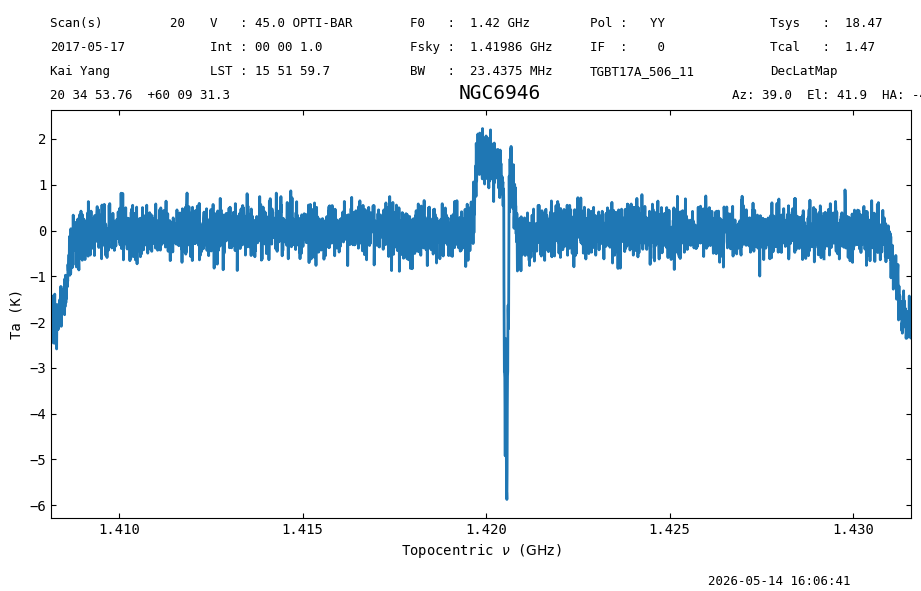

In [22]:
spec_bsub_int = sb0[len(sb0)//2].getspec(nint//2)
sp_spec_bsub_int = spec_bsub_int.plot()

In [23]:
sb0.write(output_dir / "otf_calibrated.fits", overwrite=True)

In [24]:
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt

In [25]:
cube_filename = dysh_data(example='mapping-L/outputs/otf_cube.fits')

16:06:42.339 I url: http://www.gb.nrao.edu/dysh//example_data/mapping-L/outputs/otf_cube.fits


Odd-1, did not find /bigdisk/data/gbt/dysh_data/example_data/mapping-L/outputs/otf_cube.fits
otf_cube.fits already downloaded


In [26]:
with fits.open(cube_filename) as hdu:
    data = hdu[0].data
    head = hdu[0].header
wcs = WCS(head)

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


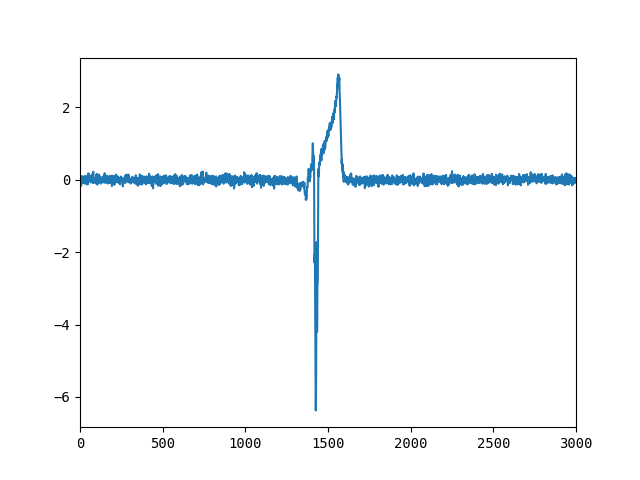

In [27]:
plt.figure()
plt.plot(data[0,:,16,16])
plt.show()

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


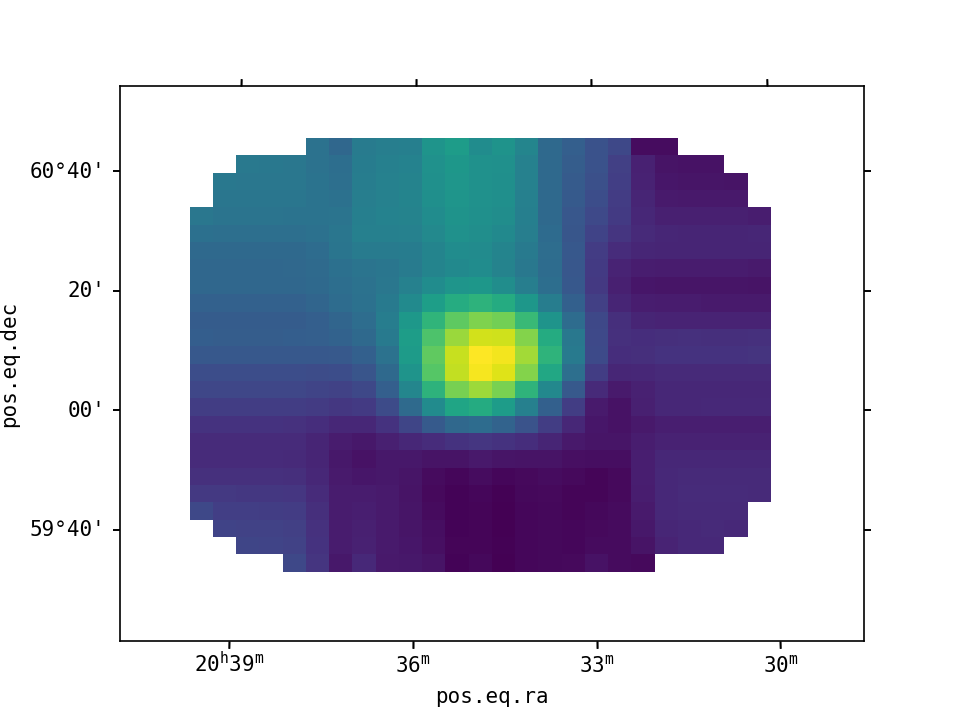

In [28]:
fig = plt.figure(dpi=150)
ax = fig.add_subplot(111, projection=wcs.celestial)
ax.imshow(data[0].mean(axis=0), origin="lower", aspect="auto")
plt.show()

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(
/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


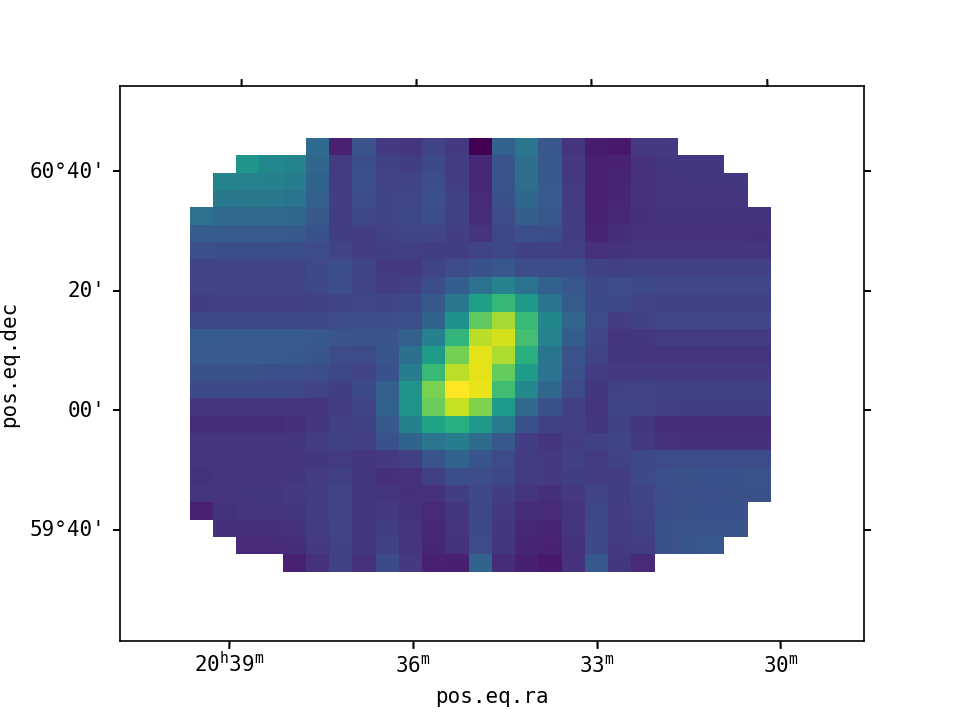

In [29]:
fig = plt.figure(dpi=150)
ax = fig.add_subplot(111, projection=wcs.celestial)
ax.imshow(data[0,1500], origin="lower", aspect="auto")
plt.show()

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


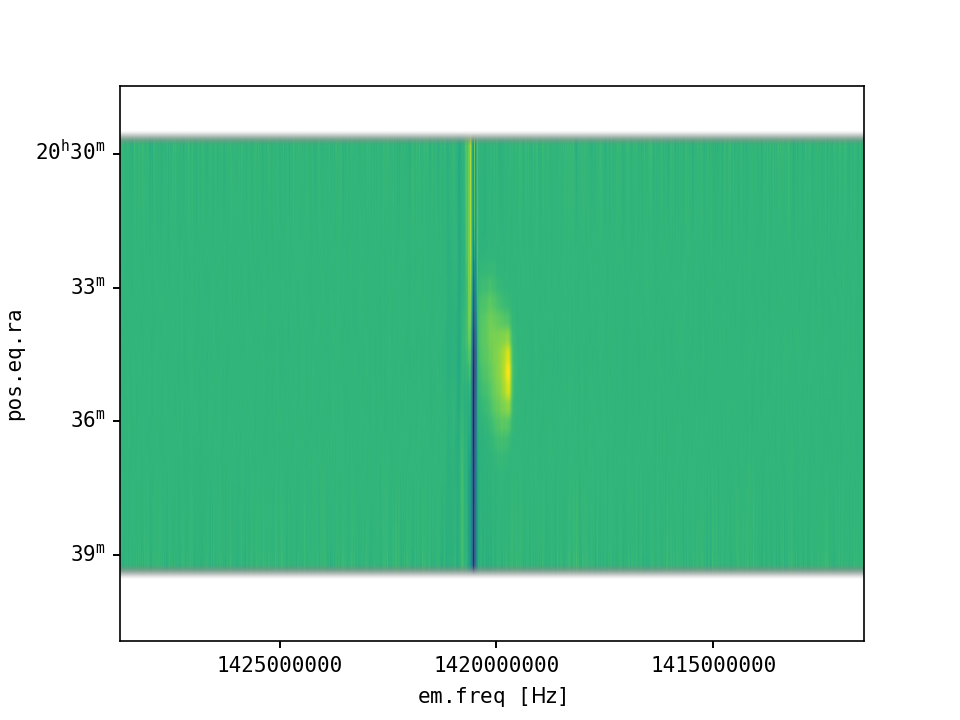

In [30]:
fig = plt.figure(dpi=150)
ax = fig.add_subplot(111, projection=wcs, slices=('y', 16, 'x', 0))
ax.imshow(data[0,:,:,16].T, origin="lower", aspect="auto")
plt.show()

In [31]:
spec_bsub_int.check_stats(0.596340) 

16:06:43.233 W Found rms=0.5962464383824206, but expected 0.59634.


In [32]:
spec_bsub_int[250:1750].radiometer()  # 1.133795557361736

16:06:43.392 I Note: found 1 NaN (masked) values


np.float64(1.133974370370993)